In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, auc,
    f1_score, recall_score, precision_score,
    confusion_matrix
)

RESULTS_DIR = '/content/drive/MyDrive/Final_Year_Project/Results/'
THRESHOLD = 0.50

COLOURS = ['red', 'blue', 'green']
LINESTYLES = ['--', '-.', '-']

In [ ]:
lr_prob = np.load(RESULTS_DIR + 'lr_y_prob.npy')
lr_true = np.load(RESULTS_DIR + 'lr_y_true.npy')

h2o_prob = np.load(RESULTS_DIR + 'h2o_y_prob.npy')
h2o_true = np.load(RESULTS_DIR + 'h2o_y_true.npy')

ag_prob = np.load(RESULTS_DIR + 'ag_y_prob.npy')
ag_true = np.load(RESULTS_DIR + 'ag_y_true.npy')

print(f'LR: {len(lr_true)} samples, {lr_true.sum()} failures')
print(f'H2O: {len(h2o_true)} samples, {h2o_true.sum()} failures')
print(f'AG: {len(ag_true)} samples, {ag_true.sum()} failures')

LR: 15329 samples, 3474 failures
H2O: 15329 samples, 3474 failures
AG: 15329 samples, 3474 failures


In [ ]:
def compute_metrics(y_true, y_prob, threshold=0.50, name='Model'):
    y_pred = (y_prob >= threshold).astype(int)
    prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    pr_auc = auc(rec_vals, prec_vals)
    roc_auc = roc_auc_score(y_true, y_prob)
    return {
        'Model': name,
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4),
        'F1': round(f1_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        '_fpr': fpr,
        '_tpr': tpr,
        '_rec': rec_vals,
        '_prec': prec_vals,
        '_y_pred': y_pred,
    }

results = [
    compute_metrics(lr_true, lr_prob, name='Logistic Regression'),
    compute_metrics(h2o_true, h2o_prob, name='H2O AutoML'),
    compute_metrics(ag_true, ag_prob, name='AutoGluon'),
]

summary_cols = ['Model', 'ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision']
df_summary = pd.DataFrame(results)[summary_cols]

print(df_summary.to_string(index=False))

              Model  ROC-AUC  PR-AUC     F1  Recall  Precision
Logistic Regression   0.8725  0.7210 0.6143  0.6647     0.5711
         H2O AutoML   0.9453  0.8862 0.7413  0.6074     0.9509
          AutoGluon   0.9604  0.9096 0.7702  0.6431     0.9600


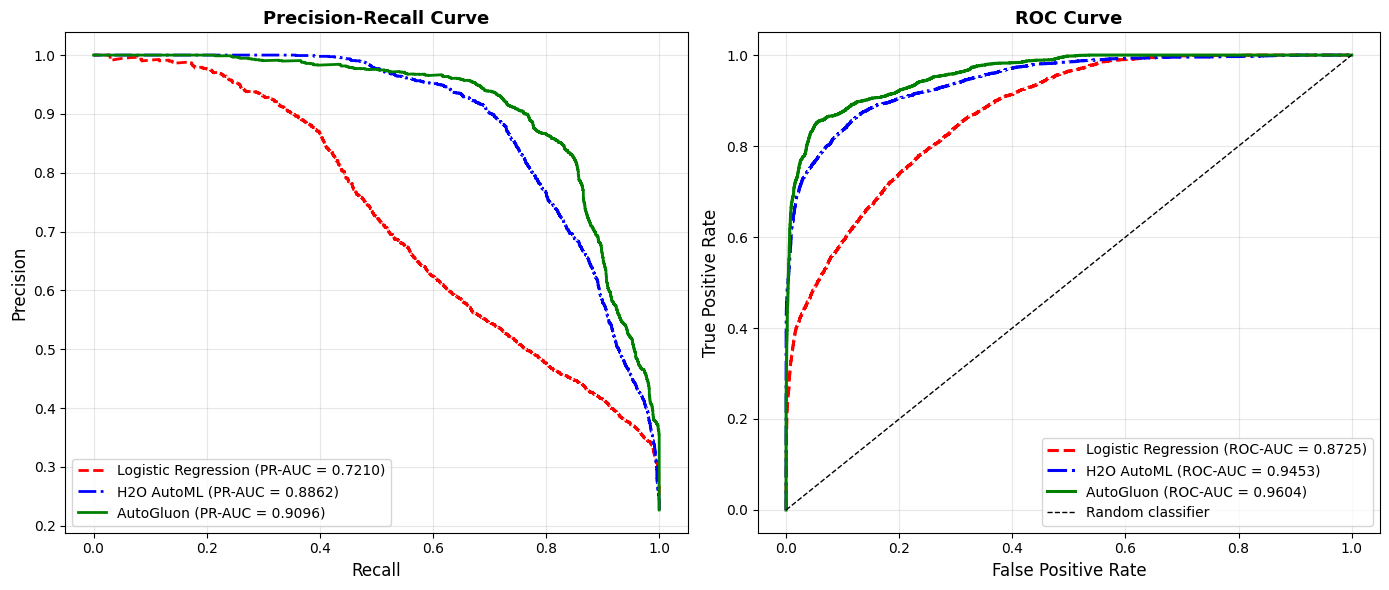

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for r, colour, linestyle in zip(results, COLOURS, LINESTYLES):
    ax.plot(r['_rec'], r['_prec'],
            color=colour,
            linestyle=linestyle,
            linewidth=2., label=f"{r['Model']} (PR-AUC = {r['PR-AUC']:.4f})")
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
for r, colour, linestyle in zip(results, COLOURS, LINESTYLES):
    ax.plot(r['_fpr'], r['_tpr'],
            color=colour,
            linestyle=linestyle,
            linewidth=2.2, label=f"{r['Model']} (ROC-AUC = {r['ROC-AUC']:.4f})")
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR + 'pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

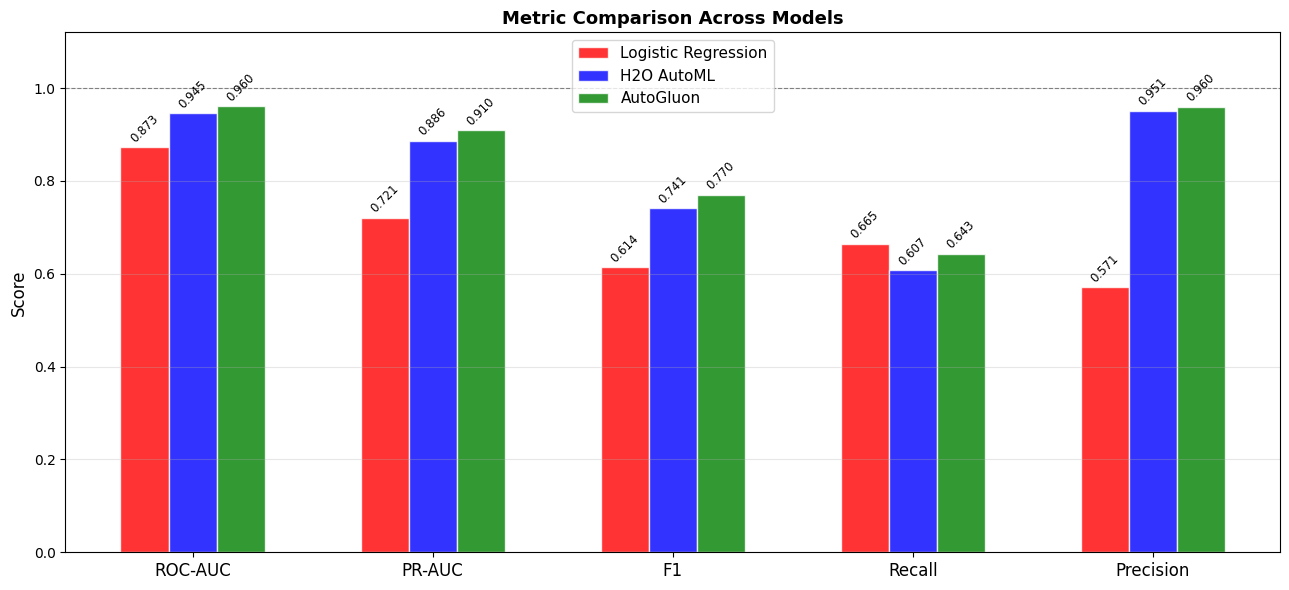

In [ ]:
metrics = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision']
x = np.arange(len(metrics))
width = 0.2
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(13, 6))

for r, colour, offset in zip(results, COLOURS, offsets):
    vals = [r[m] for m in metrics]
    bars = ax.bar(x + offset, vals, width,
                  label=r['Model'], color=colour,
                  alpha=0.8, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Metric Comparison Across Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

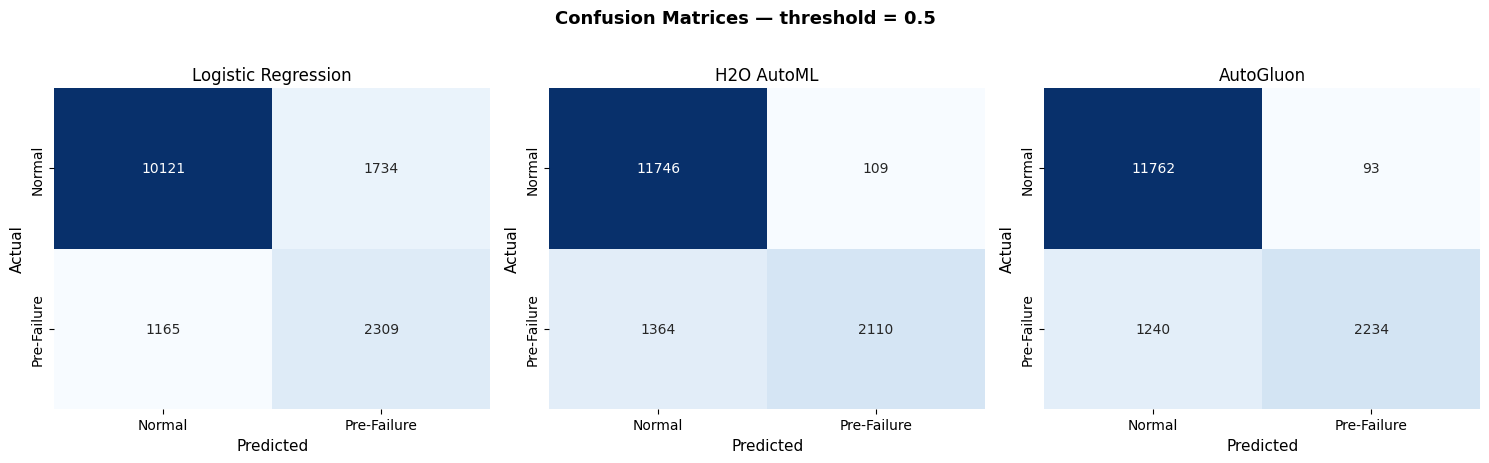

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, r, y_true in zip(axes, results, [lr_true, h2o_true, ag_true]):
    cm = confusion_matrix(y_true, r['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Pre-Failure'],
                yticklabels=['Normal', 'Pre-Failure'],
                ax=ax, cbar=False)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(r['Model'], fontsize=12)

plt.suptitle(f'Confusion Matrices — threshold = {THRESHOLD}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print(df_summary.to_string(index=False))

best_roc = df_summary.loc[df_summary['ROC-AUC'].idxmax(), 'Model']
best_pr = df_summary.loc[df_summary['PR-AUC'].idxmax(), 'Model']
best_f1 = df_summary.loc[df_summary['F1'].idxmax(), 'Model']
best_rec = df_summary.loc[df_summary['Recall'].idxmax(), 'Model']

print(f'Best ROC-AUC: {best_roc}')
print(f'Best PR-AUC: {best_pr}')
print(f'Best F1: {best_f1}')
print(f'Best Recall: {best_rec}')

              Model  ROC-AUC  PR-AUC     F1  Recall  Precision
Logistic Regression   0.8725  0.7210 0.6143  0.6647     0.5711
         H2O AutoML   0.9453  0.8862 0.7413  0.6074     0.9509
          AutoGluon   0.9604  0.9096 0.7702  0.6431     0.9600
Best ROC-AUC: AutoGluon
Best PR-AUC: AutoGluon
Best F1: AutoGluon
Best Recall: Logistic Regression
